# 正则化
想象一下，我们正在学习骑自行车，一开始，可能会非常紧张，双手紧紧抓住车把，身体僵硬，试图记住每一个动作细节。这种过度关注细节、试图完美控制每一个微小动作的状态，在机器学习中被称为 过拟合。

我们的模型（就像初学时的你）过于复杂，完美地记住了训练数据中的每一个样本，甚至包括噪声和随机波动，导致它在面对新的、未见过的数据（比如实际骑行上路）时，表现得很差，缺乏泛化能力。

正则化 就是为解决这个问题而生的核心技术，它的核心思想是：给模型的学习热情降降温，防止它钻牛角尖，从而提升其在新环境下的适应能力。简单来说，正则化通过在模型训练的目标函数（损失函数）中增加一个额外的惩罚项，来限制模型的复杂度，避免其过度依赖训练数据中的特定模式。

本文将带你深入理解正则化的原理、常见方法及其在工程实践中的应用。

------

## 基础概念 : 偏差与方差的权衡
在理解正则化之前，我们需要先了解机器学习中的一个核心概念：偏差-方差权衡（Bias-Variance Tradeoff）。这个概念描述了模型在训练数据和新数据上的表现之间的关系。

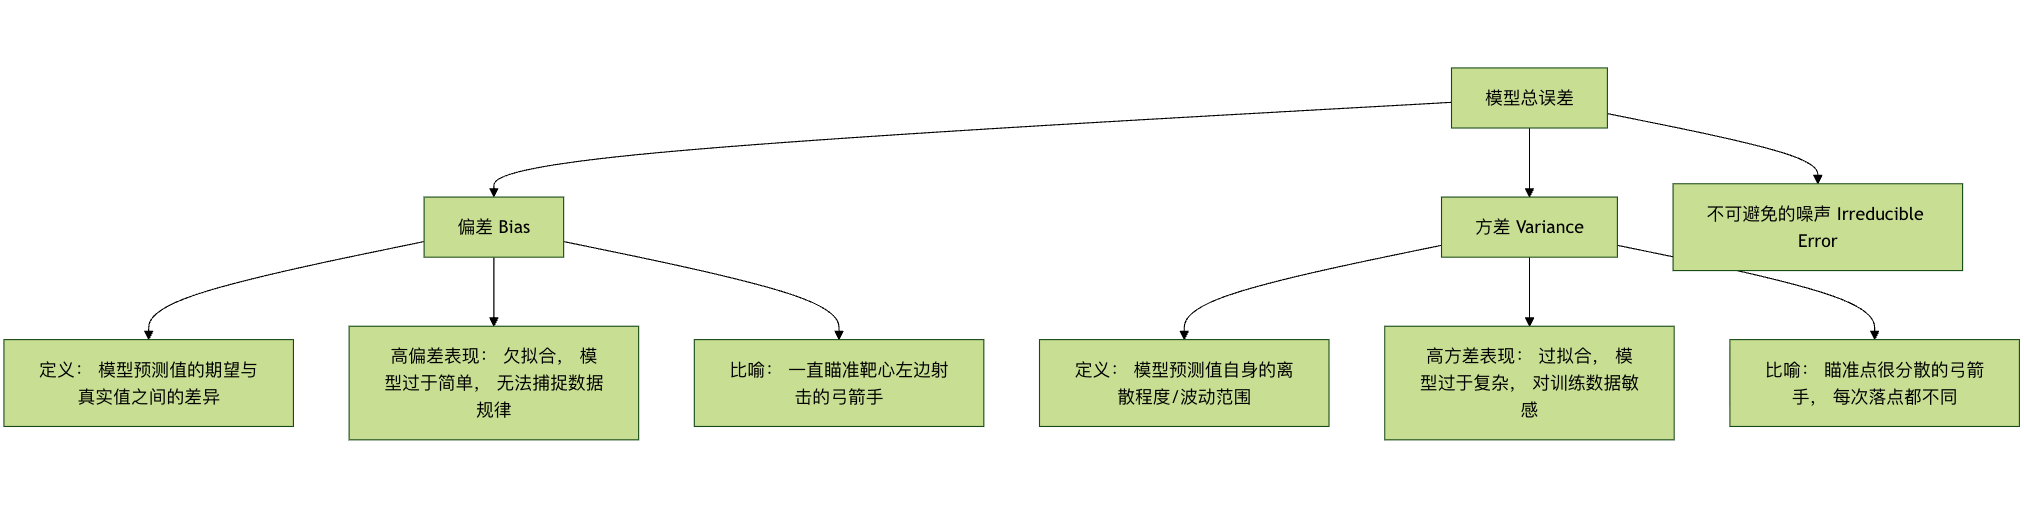

偏置（Bias）和方差（Variance）是衡量模型泛化能力的两个重要指标：

- **偏置**：指模型对真实规律的“平均预测”与真实值之间的偏离程度。  
    如果记真实目标函数为 \(f(x)\)，模型在不同训练集上学到的预测为 \(\hat{f}(x)\)，那么偏置可直观理解为：
    \[
    \text{Bias}(\hat{f}(x)) = \mathbb{E}[\hat{f}(x)] - f(x)
    \]
    - 偏置高，通常说明模型太简单，容易**欠拟合**。  
    - 例如：用一条直线去拟合明显弯曲的数据。

- **方差**：指模型对训练数据变化的敏感程度。  
    方差可以表示为：
    \[
    \text{Var}(\hat{f}(x)) = \mathbb{E}\big[(\hat{f}(x) - \mathbb{E}[\hat{f}(x)])^2\big]
    \]
    - 方差高，通常说明模型太复杂，容易**过拟合**。  
    - 例如：训练数据稍微变动，模型结果就变化很大。

### 误差分解
在监督学习中，模型在测试集上的期望误差通常可以理解为由三部分组成：
\[
\mathbb{E}\big[(y - \hat{f}(x))^2\big] = \text{Bias}^2 + \text{Var} + \sigma^2
\]
其中：
- \(\text{Bias}^2\)：偏差平方
- \(\text{Var}\)：方差
- \(\sigma^2\)：不可避免的噪声误差

### 直观理解
- **高偏置、低方差**：模型过于简单，比较稳定，但不够准确。  
- **低偏置、高方差**：模型很灵活，训练集上表现很好，但对新数据不稳定。  
- **理想情况**：在偏置和方差之间取得平衡，使模型既不过于简单，也不过于复杂。

### 与正则化的关系
正则化的主要作用之一，就是**降低模型方差**，减少过拟合风险。  
例如，带有正则项的目标函数常写为：
\[
\mathcal{L}_{\text{reg}} = \mathcal{L}_{\text{data}} + \lambda \Omega(w)
\]
其中：
- \(\mathcal{L}_{\text{data}}\) 是原始损失函数
- \(\Omega(w)\) 是正则项
- \(\lambda\) 控制正则化强度

但如果正则化过强，也可能让模型偏置增加，导致欠拟合。  
因此，正则化本质上是在**偏置与方差之间做权衡**。